In [1]:
#using DifferentialEquations # for the actual time evolution
#using OrdinaryDiffEq # for ODEs
using Plots # for plotting
using Base.Threads # for parallelization
using StaticArrays # somehow needed to use multiple variables in DifferentialEquations.jl

using Plots, LaTeXStrings, Colors
using Plots.PlotMeasures
using LinearAlgebra

using Random, Distributions

using FFTW # discrete Fourier transform

using JLD2 # for file saving

In [47]:
col_wave = RGBA(202/256,0/256,32/256);
col_Gauss = RGBA(0,136/256,55/256);
col_rand = :lightgray #RGBA(146/256,197/256,222/256);

:lightgray

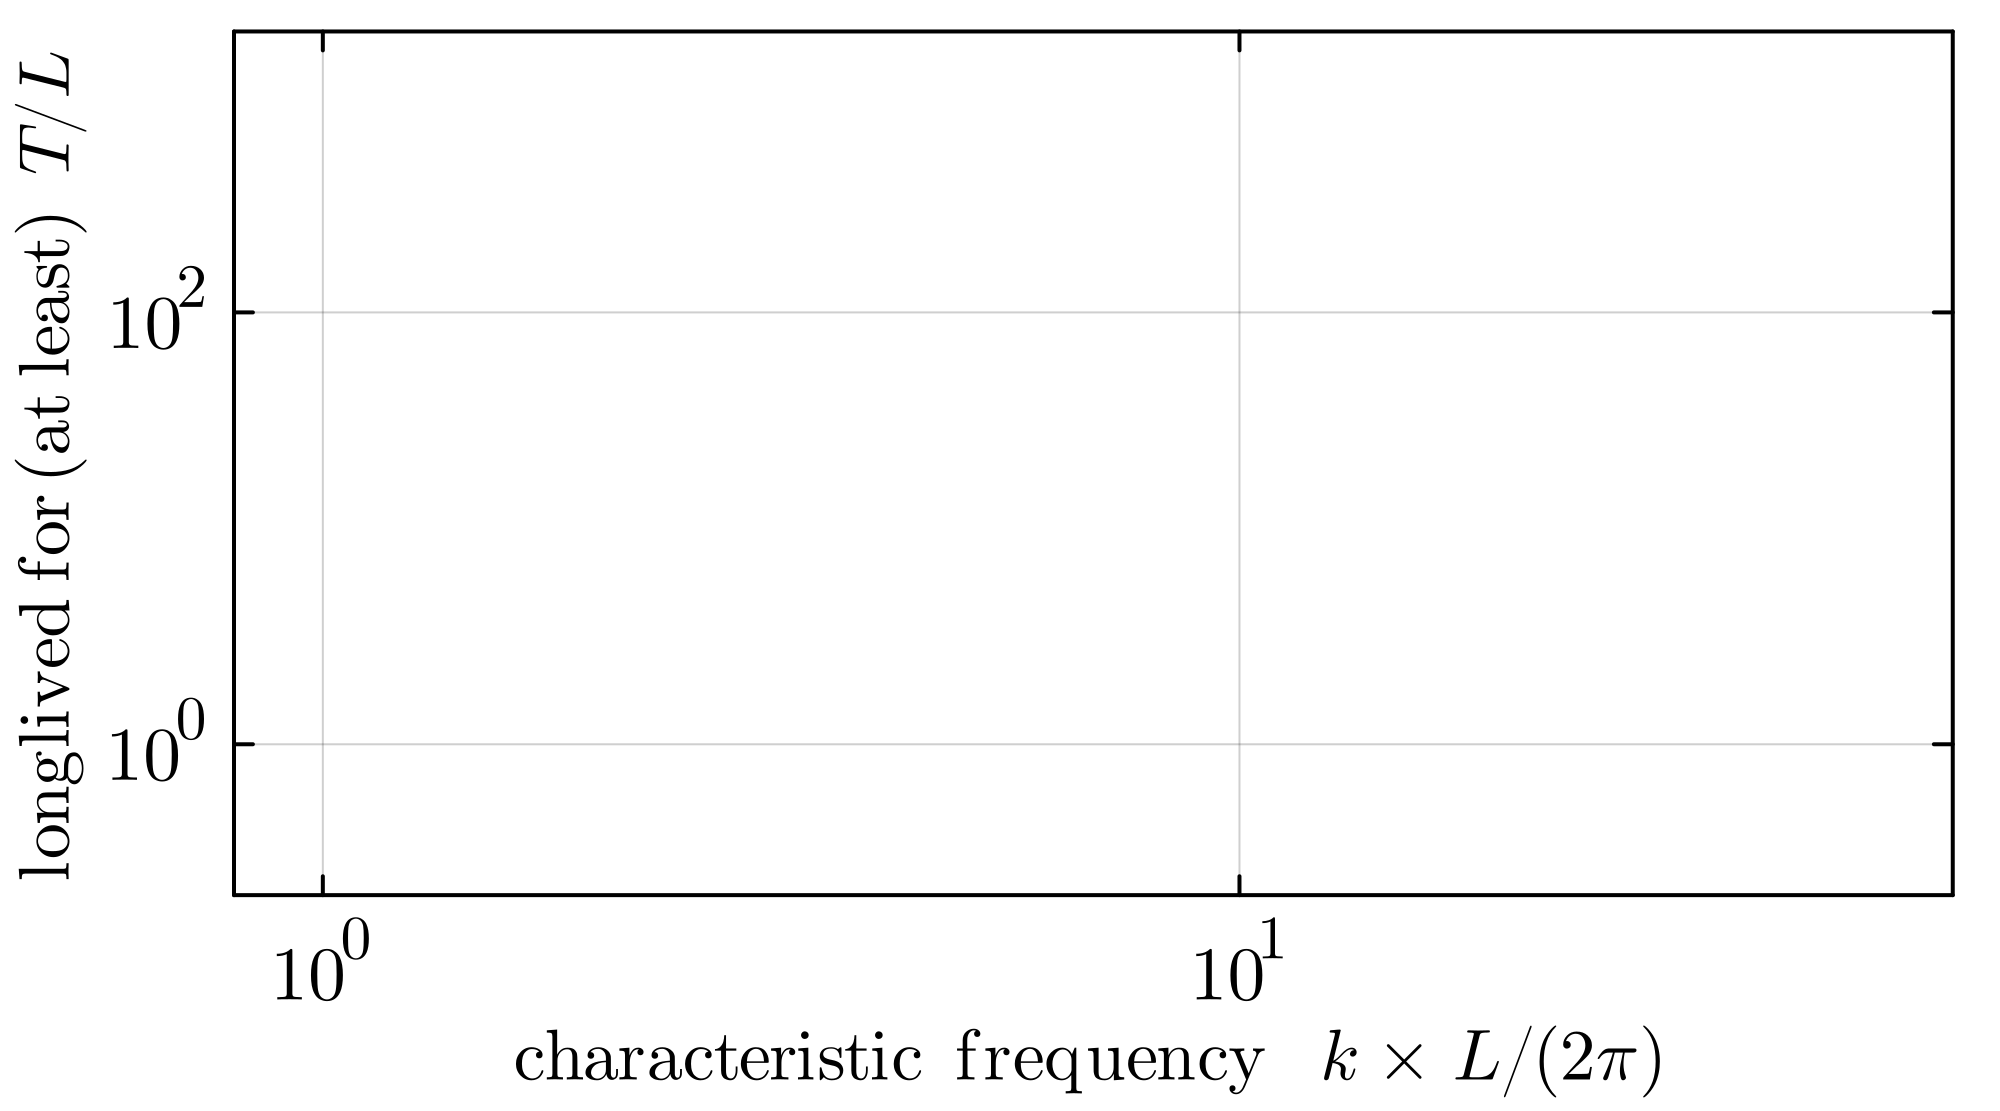

In [48]:
scalingPlot = plot(
    layout=(1), framestyle=:box, dpi = 400, size = (500,500/1.8),  
    legend=:bottomright,
    guidefont = "Computer Modern", tickfont = "Computer Modern",
    xguidefontsize = 12, yguidefontsize = 12, 
    legendfontsize = 12, titlefontsize = 12, tickfontsize = 12,
    yscale=:log, 
    ylim=(2e-1,2e3),
    xscale=:log,
    xlim=(8e-1,6e1),
    xlabel=L"$\textrm{characteristic\;\;frequency}\quad k\times L/(2\pi)$", 
    ylabel=L"$\textrm{longlived\;for\;(at\;least)}\;\; T/L$",
    bottom_margin = 10px,
    top_margin = 0px
)

In [49]:
dir = "03_rand/dat"
stableRandomSeeds = readdir(dir)
length(stableRandomSeeds)

for i in 1:length(stableRandomSeeds)
    print(stableRandomSeeds[i],"\n")
end

1076323
29812
65525


In [50]:
filenames = []

for seeds in stableRandomSeeds
    files = readdir(joinpath(dir, seeds))
    print(length(files),"\n")
    push!(filenames, [joinpath(dir, seeds, file) for file in files])
end

8
8
8


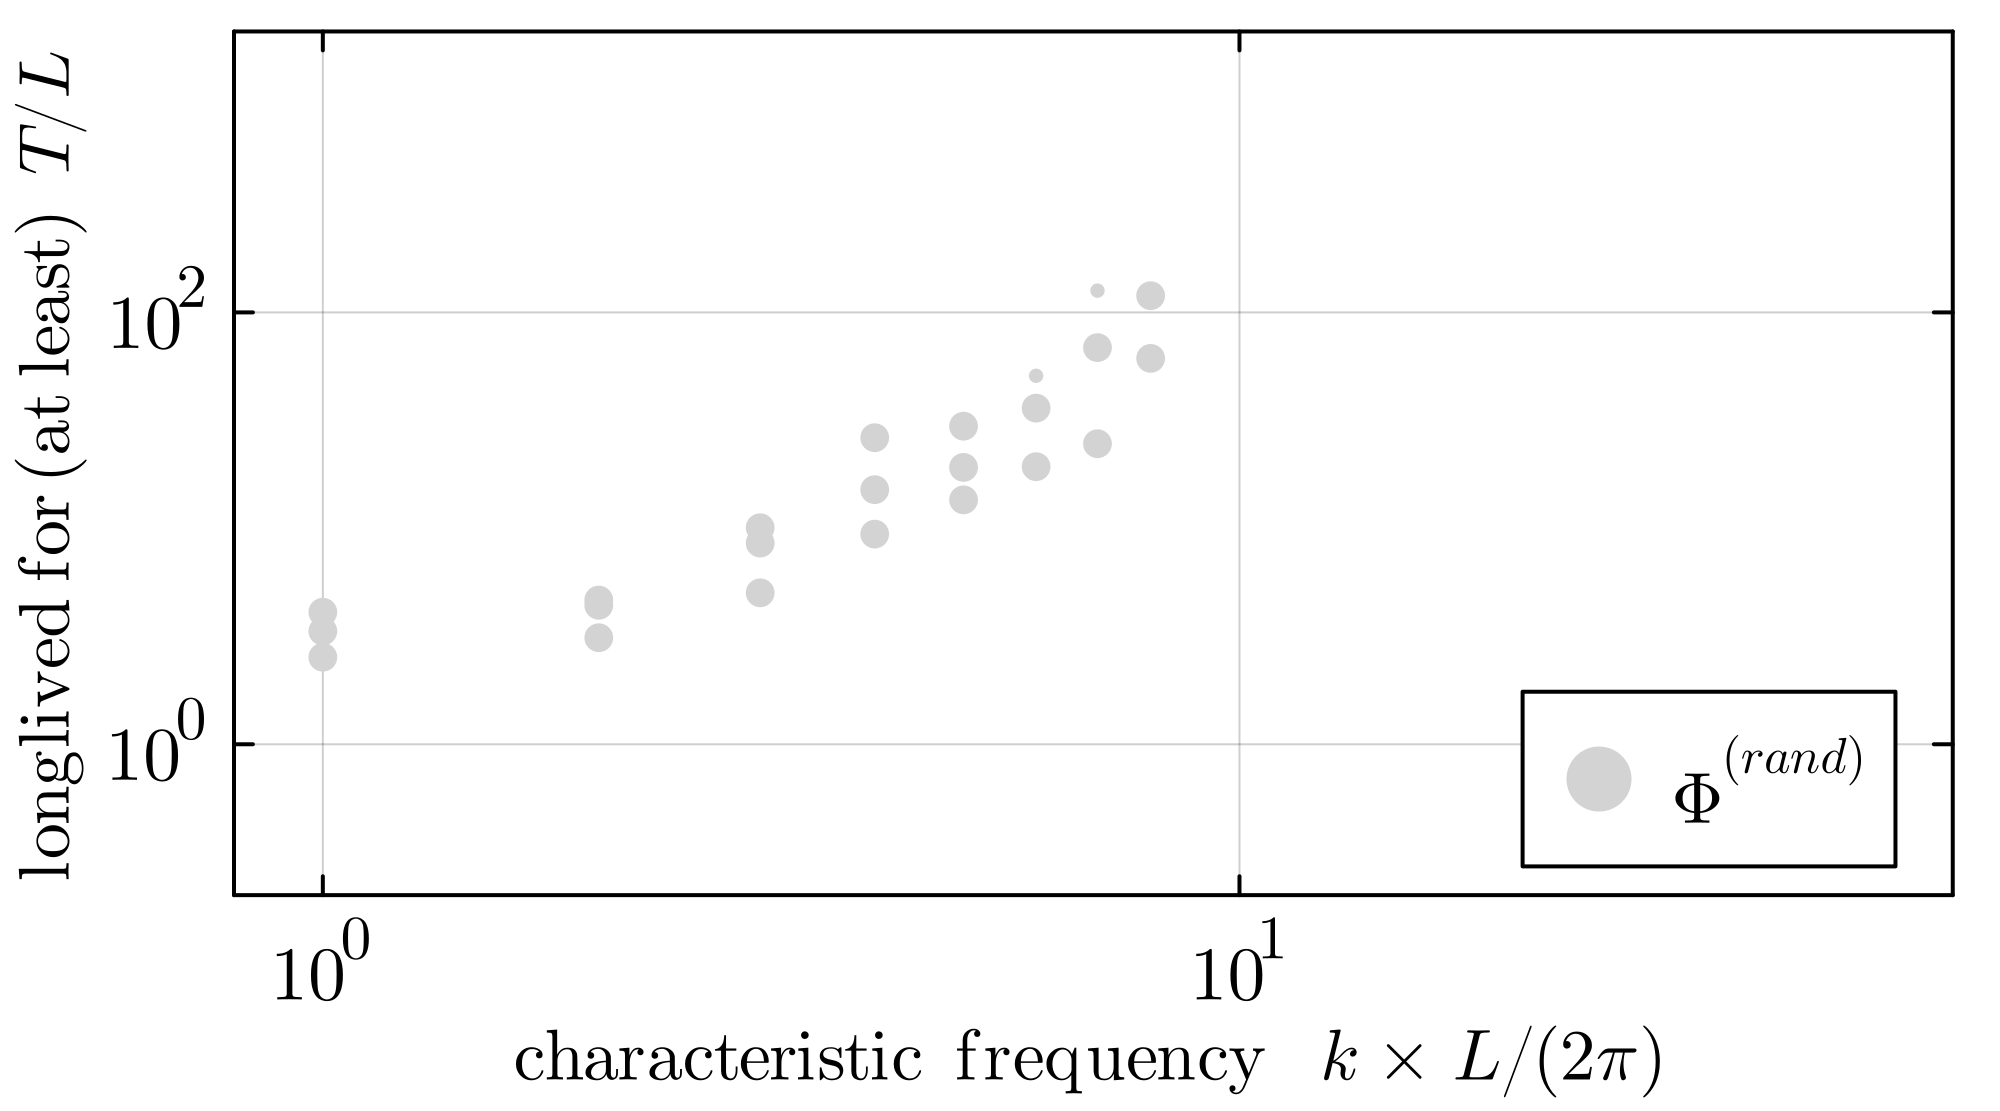

In [51]:
for i in 1:length(stableRandomSeeds)
    
    param_values = []
    param_values_lower_bound_only = []

    times = []
    times_lower_bound_only = []
    
    for filename in filenames[i]

        # read the data

        @load joinpath(pwd(), filename) param stable_until lower_bound_only #timesteps hamiltonianTab hamPhiTab hamChiTab

        if !lower_bound_only
            push!(param_values, param)
            push!(times, stable_until)
            push!(param_values_lower_bound_only, param)
            push!(times_lower_bound_only, stable_until)
        else
            push!(param_values_lower_bound_only, param)
            push!(times_lower_bound_only, stable_until)
        end 
    end
    
    # make sure to sort pairs of data in order ascending with 1/A
    perm = sortperm(param_values)
    times = times[perm]
    param_values = param_values[perm]
    
    perm = sortperm(param_values_lower_bound_only)
    times_lower_bound_only = times_lower_bound_only[perm]
    param_values_lower_bound_only = param_values_lower_bound_only[perm]
    
    labelval = false
    if i==1
        labelval = L"$\Phi^\mathit{(rand)}$"
    end
    
    plot!(
        scalingPlot, 
        param_values_lower_bound_only, times_lower_bound_only,
        seriestype=:scatter,
        marker=:circle, markersize=2, linewidth=0.5, markerstrokewidth=0.5,
        color=col_rand, markerstrokecolor=col_rand, markercolor=col_rand,
        label=false
    )

    plot!(
        scalingPlot, 
        param_values, times,
        seriestype=:scatter,
        marker=:circle, markersize=4, linewidth=0.5, markerstrokewidth=0.5,
        color=col_rand, markerstrokecolor=col_rand, markercolor=col_rand,
        label=labelval
    )
    
end

scalingPlot

In [52]:
dir = "02_wave/dat"
stableRandomSeeds = readdir(dir)
length(stableRandomSeeds)

for i in 1:length(stableRandomSeeds)
    print(stableRandomSeeds[i],"\n")
end

0


In [53]:
filenames = []

for seeds in stableRandomSeeds
    files = readdir(joinpath(dir, seeds))
    print(length(files),"\n")
    push!(filenames, [joinpath(dir, seeds, file) for file in files])
end

11


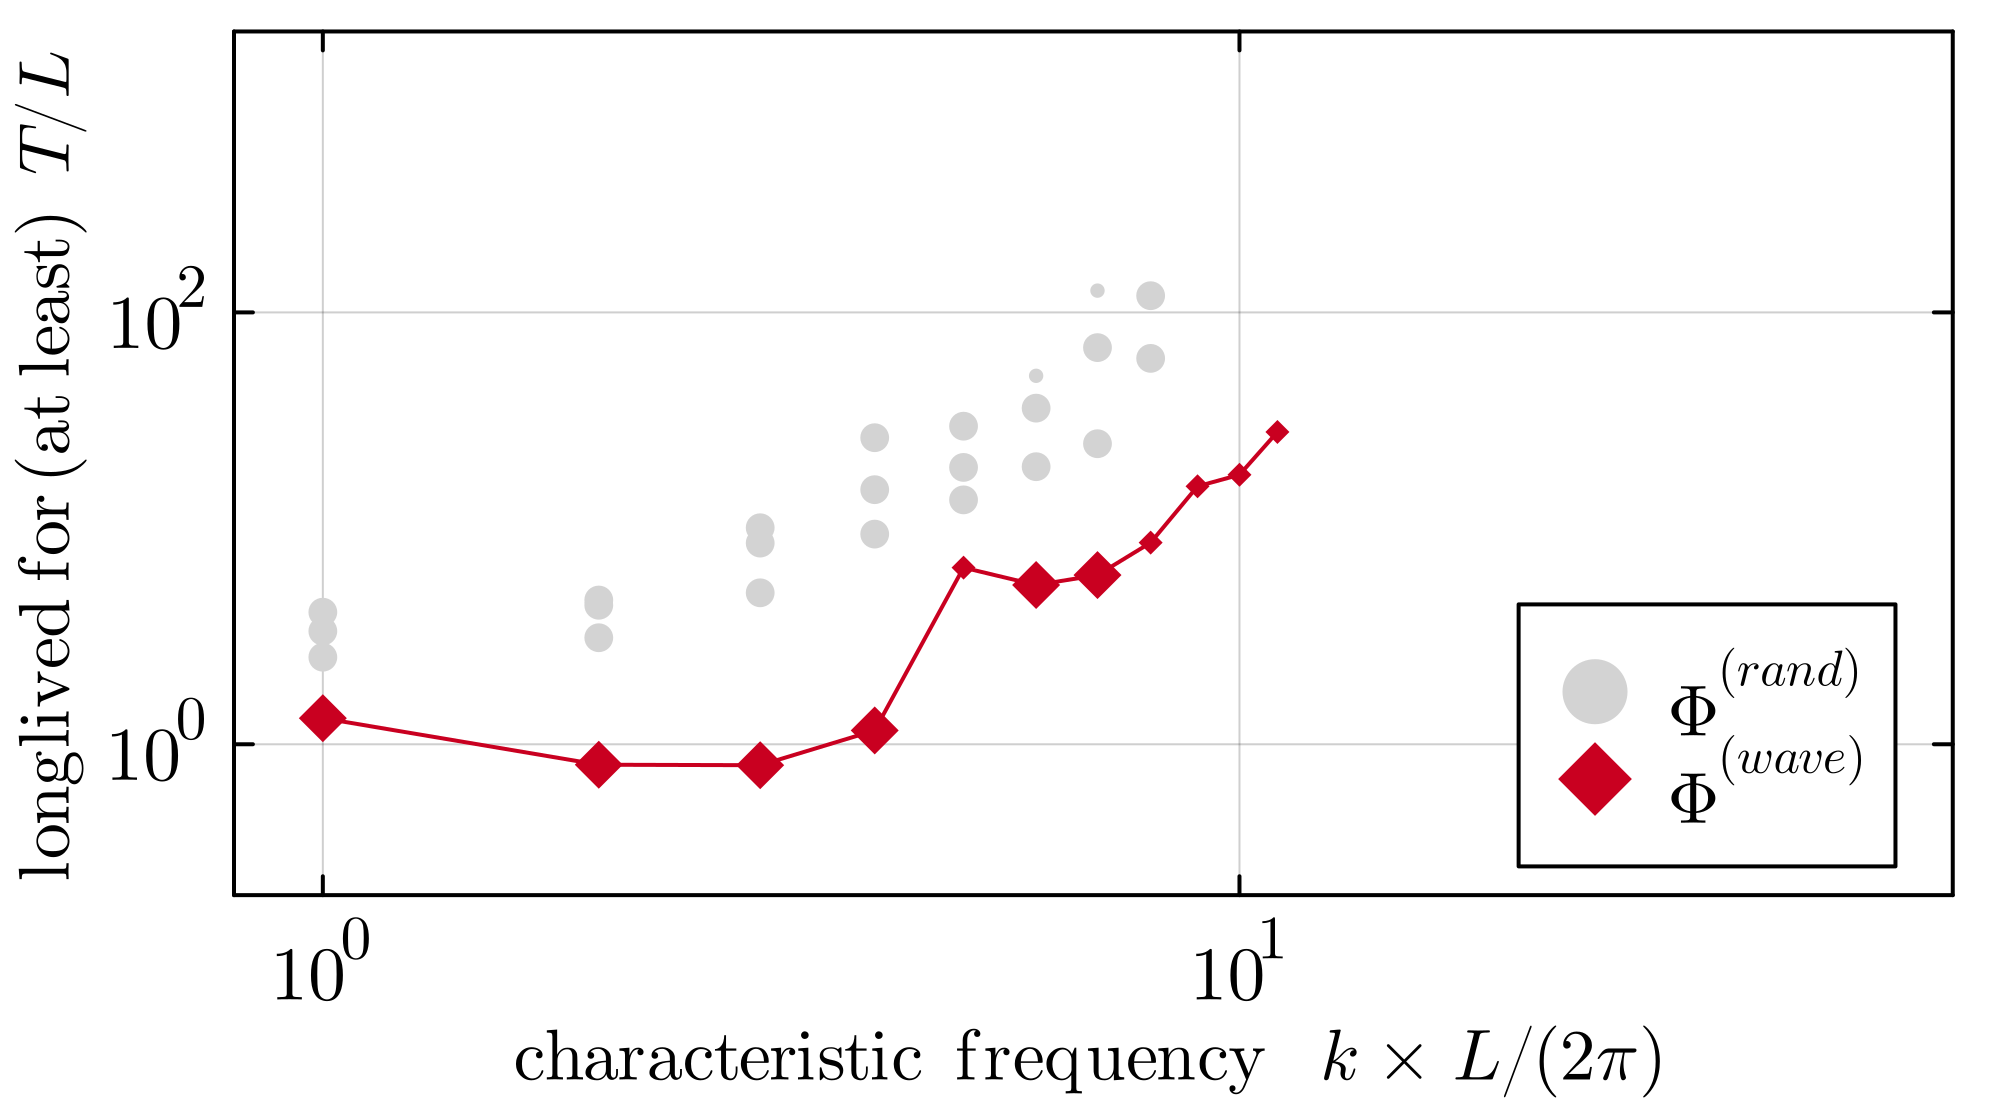

In [54]:
for i in 1:length(stableRandomSeeds)
    
    param_values = []
    param_values_lower_bound_only = []

    times = []
    times_lower_bound_only = []
    
    for filename in filenames[i]

        # read the data

        @load joinpath(pwd(), filename) param stable_until lower_bound_only #timesteps hamiltonianTab hamPhiTab hamChiTab

        if !lower_bound_only
            push!(param_values, param)
            push!(times, stable_until)
            push!(param_values_lower_bound_only, param)
            push!(times_lower_bound_only, stable_until)
        else
            push!(param_values_lower_bound_only, param)
            push!(times_lower_bound_only, stable_until)
        end 
    end
    
    # make sure to sort pairs of data in order ascending with 1/A
    perm = sortperm(param_values)
    times = times[perm]
    param_values = param_values[perm]
    
    perm = sortperm(param_values_lower_bound_only)
    times_lower_bound_only = times_lower_bound_only[perm]
    param_values_lower_bound_only = param_values_lower_bound_only[perm]
    
    plot!(
        scalingPlot, 
        param_values_lower_bound_only, times_lower_bound_only,
        #seriestype=:scatter,
        marker=:diamond, markersize=3, linewidth=1, markerstrokewidth=0.5,
        color=col_wave, markerstrokecolor=col_wave, markercolor=col_wave,
        label=false
    )

    plot!(
        scalingPlot, 
        param_values, times,
        seriestype=:scatter,
        marker=:diamond, markersize=6, linewidth=1, markerstrokewidth=0.5,
        color=col_wave, markerstrokecolor=col_wave, markercolor=col_wave,
        label=L"$\Phi^\mathit{(wave)}$"
    )
    
end

scalingPlot

In [55]:
dir = "01_Gauss/dat"
stableRandomSeeds = readdir(dir)
length(stableRandomSeeds)

for i in 1:length(stableRandomSeeds)
    print(stableRandomSeeds[i],"\n")
end

0


In [56]:
filenames = []

for seeds in stableRandomSeeds
    files = readdir(joinpath(dir, seeds))
    print(length(files),"\n")
    push!(filenames, [joinpath(dir, seeds, file) for file in files])
end

4


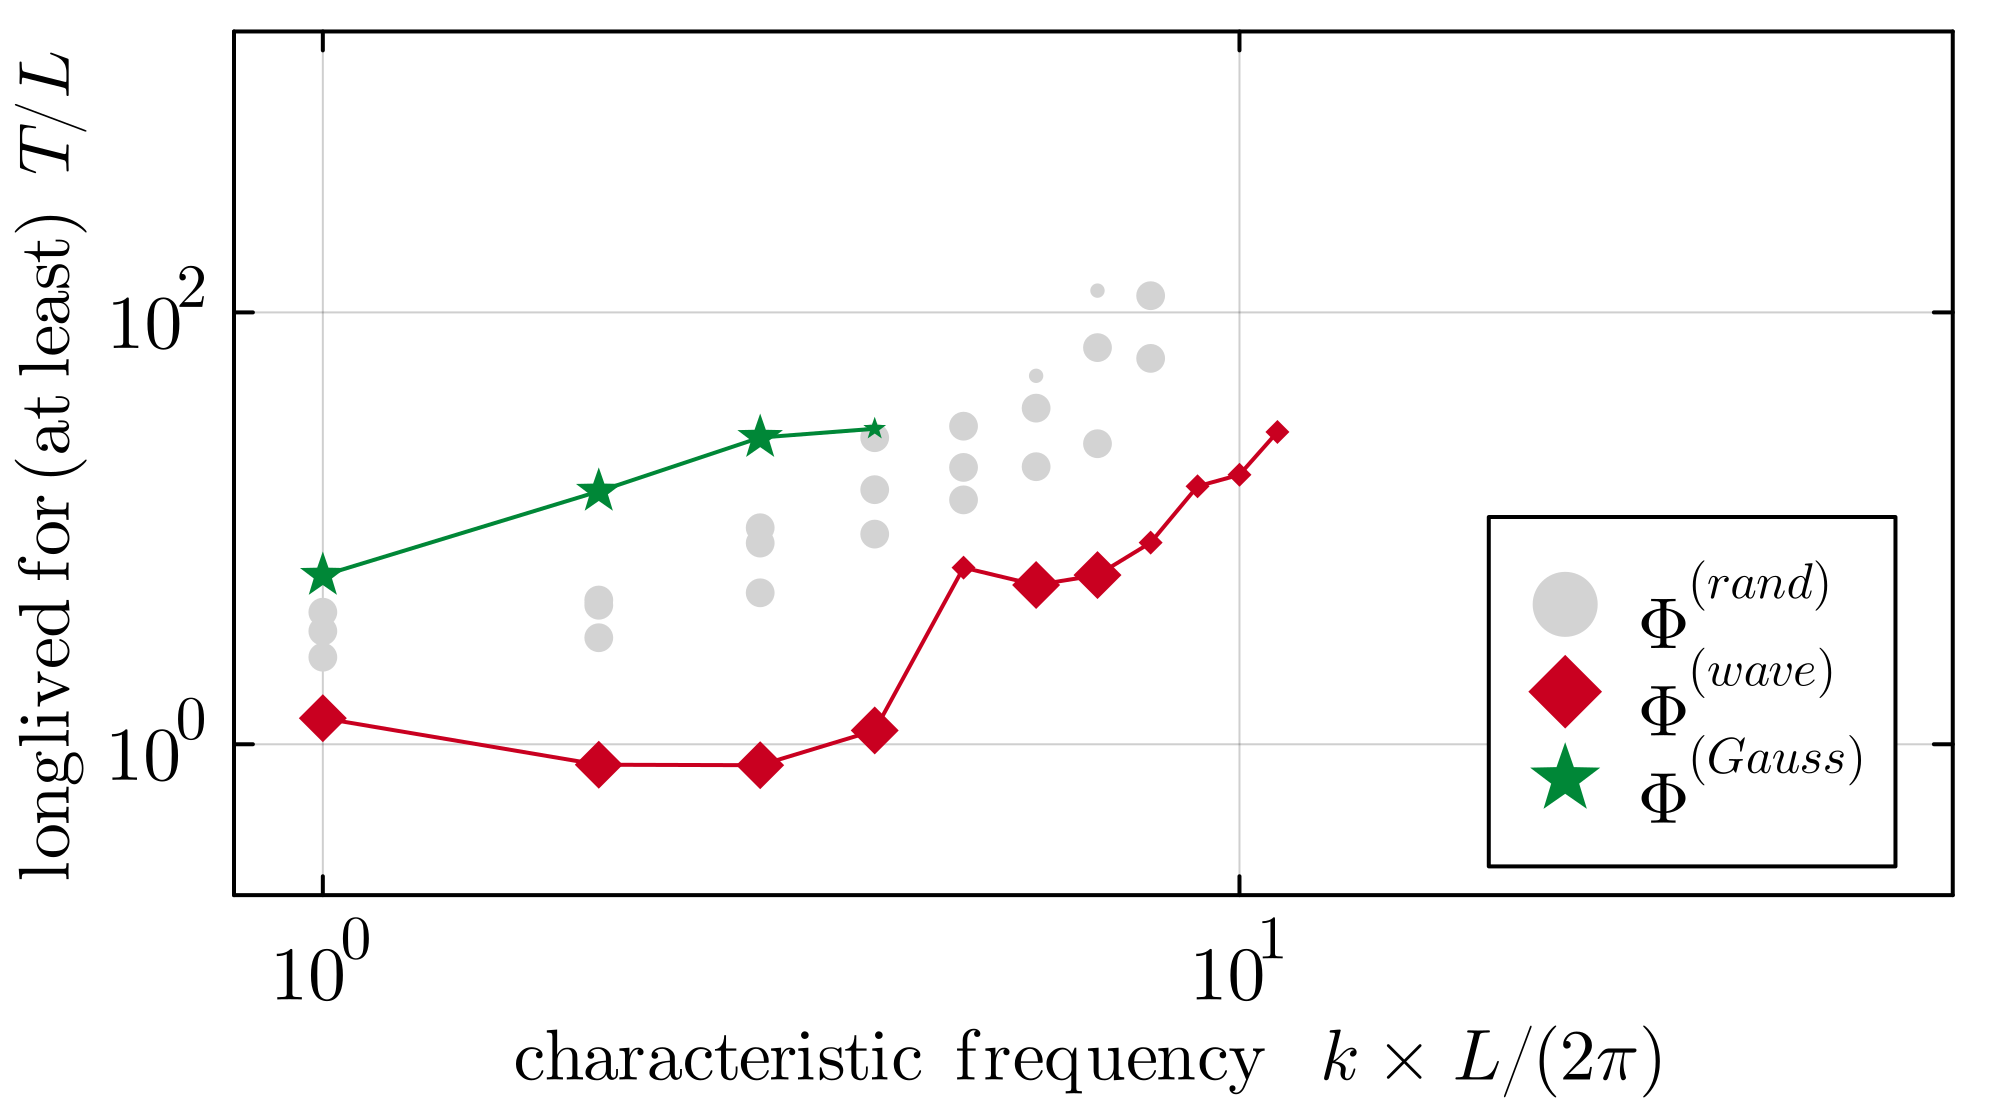

In [57]:
for i in 1:length(stableRandomSeeds)
    
    param_values = []
    param_values_lower_bound_only = []

    times = []
    times_lower_bound_only = []
    
    for filename in filenames[i]

        # read the data

        @load joinpath(pwd(), filename) param stable_until lower_bound_only #timesteps hamiltonianTab hamPhiTab hamChiTab

        if !lower_bound_only
            push!(param_values, param)
            push!(times, stable_until)
            push!(param_values_lower_bound_only, param)
            push!(times_lower_bound_only, stable_until)
        else
            push!(param_values_lower_bound_only, param)
            push!(times_lower_bound_only, stable_until)
        end 
    end
    
    # make sure to sort pairs of data in order ascending with 1/A
    perm = sortperm(param_values)
    times = times[perm]
    param_values = param_values[perm]
    
    perm = sortperm(param_values_lower_bound_only)
    times_lower_bound_only = times_lower_bound_only[perm]
    param_values_lower_bound_only = param_values_lower_bound_only[perm]
    
    plot!(
        scalingPlot, 
        param_values_lower_bound_only, times_lower_bound_only,
        #seriestype=:scatter,
        marker=:star, markersize=3, linewidth=1, markerstrokewidth=0.5,
        color=col_Gauss, markerstrokecolor=col_Gauss, markercolor=col_Gauss,
        label=false
    )

    plot!(
        scalingPlot, 
        param_values, times,
        seriestype=:scatter,
        marker=:star, markersize=6, linewidth=1, markerstrokewidth=0.5,
        color=col_Gauss, markerstrokecolor=col_Gauss, markercolor=col_Gauss,
        label=L"$\Phi^\mathit{(Gauss)}$"
    )
    
end

scalingPlot

In [58]:
savefig(scalingPlot, joinpath(pwd(), "scaling_T_of_k_loglog.png"));

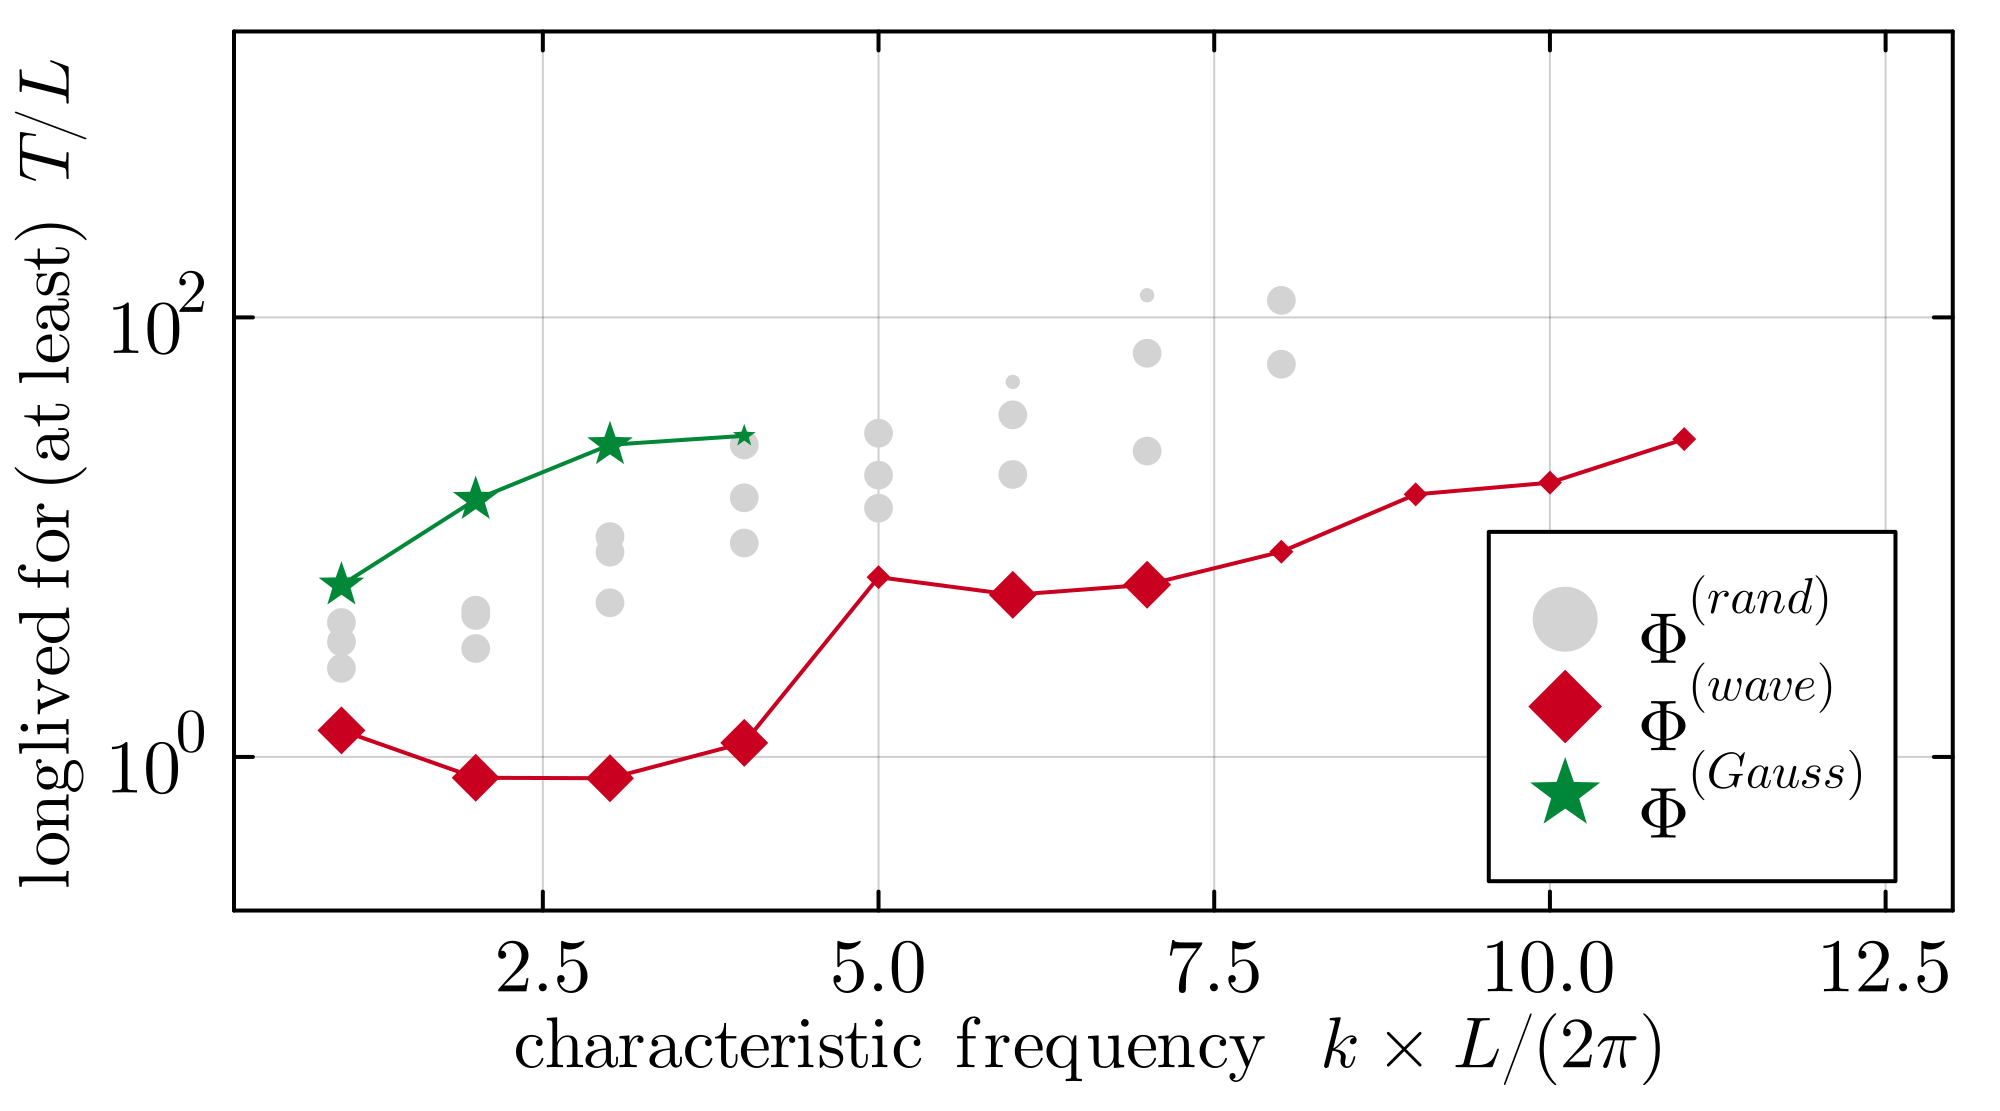

In [59]:
plot!(scalingPlot,xscale=:linear,xlim=(0.2,13))

In [60]:
savefig(scalingPlot, joinpath(pwd(), "scaling_T_of_k_log.png"));